In [1]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#bring the two csv's to the notebook
fantasy_df = pd.read_csv("../data/goodreads_fan_books_clean.csv")
scifi_df = pd.read_csv("../data/goodreads_sf_books_clean.csv")

In [3]:
#top 5 of fantasy
fantasy_df.head()



,Unnamed: 0,title,author,pub_year,avg_rate,num_rate,shelved,series_name,series_num
0,0,Harry Potter and the Philosopher's Stone,J.K. Rowling,1997,4.47,8827238,71462,Harry Potter,1.0
1,1,Harry Potter and the Chamber of Secrets,J.K. Rowling,1998,4.43,3409926,59741,Harry Potter,2.0
2,2,Harry Potter and the Prisoner of Azkaban,J.K. Rowling,1999,4.58,3595393,59290,Harry Potter,3.0
3,3,The Hobbit,J.R.R. Tolkien,1937,4.28,3483329,58644,NaN,NaN
4,4,Harry Potter and the Goblet of Fire,J.K. Rowling,2000,4.57,3164528,57211,Harry Potter,4.0


In [4]:
#top 5 of scifi
scifi_df.head()

,Unnamed: 0,title,author,pub_year,avg_rate,num_rate,shelved,series_name,series_num
0,0,Dune,Frank Herbert,1965,4.25,1128771,17356,Dune,1.0
1,1,Ender's Game,Orson Scott Card,1985,4.30,1273765,16692,Ender's Saga,1.0
2,2,The Hitchhiker's Guide to the Galaxy,Douglas Adams,1979,4.23,1679109,15896,Hitchhiker's Guide to the Galaxy,1.0
3,3,The Martian,Andy Weir,2011,4.41,990146,14130,NaN,NaN
4,4,Ready Player One,Ernest Cline,2011,4.24,1044522,12187,Ready Player One,1.0


In [5]:
#fantasty data types
fantasy_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1248 non-null   int64  
 1   title        1248 non-null   str    
 2   author       1248 non-null   str    
 3   pub_year     1248 non-null   int64  
 4   avg_rate     1248 non-null   float64
 5   num_rate     1248 non-null   int64  
 6   shelved      1248 non-null   int64  
 7   series_name  1072 non-null   str    
 8   series_num   1071 non-null   float64
dtypes: float64(2), int64(4), str(3)
memory usage: 87.9 KB


In [6]:
#scifi data types
scifi_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1246 entries, 0 to 1245
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1246 non-null   int64  
 1   title        1246 non-null   str    
 2   author       1246 non-null   str    
 3   pub_year     1246 non-null   int64  
 4   avg_rate     1246 non-null   float64
 5   num_rate     1246 non-null   int64  
 6   shelved      1246 non-null   int64  
 7   series_name  766 non-null    str    
 8   series_num   766 non-null    float64
dtypes: float64(2), int64(4), str(3)
memory usage: 87.7 KB


In [7]:
#dropping colomns
fantasy_df = fantasy_df.drop(columns=["Unnamed: 0"])
scifi_df = scifi_df.drop(columns=["Unnamed: 0"])

In [8]:
#adding respective generes column
fantasy_df["genre"] = "Fantasy"
scifi_df["genre"] = "Sci-Fi"

In [9]:
#merging the two csv's
books_df = pd.concat([fantasy_df, scifi_df], ignore_index=True)

In [10]:
#checking the top 5 rows of my new combined db
books_df.head()

,title,author,pub_year,avg_rate,num_rate,shelved,series_name,series_num,genre
0,Harry Potter and the Philosopher's Stone,J.K. Rowling,1997,4.47,8827238,71462,Harry Potter,1.0,Fantasy
1,Harry Potter and the Chamber of Secrets,J.K. Rowling,1998,4.43,3409926,59741,Harry Potter,2.0,Fantasy
2,Harry Potter and the Prisoner of Azkaban,J.K. Rowling,1999,4.58,3595393,59290,Harry Potter,3.0,Fantasy
3,The Hobbit,J.R.R. Tolkien,1937,4.28,3483329,58644,NaN,NaN,Fantasy
4,Harry Potter and the Goblet of Fire,J.K. Rowling,2000,4.57,3164528,57211,Harry Potter,4.0,Fantasy


In [11]:
#checking data types of combined db
books_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2494 entries, 0 to 2493
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        2494 non-null   str    
 1   author       2494 non-null   str    
 2   pub_year     2494 non-null   int64  
 3   avg_rate     2494 non-null   float64
 4   num_rate     2494 non-null   int64  
 5   shelved      2494 non-null   int64  
 6   series_name  1838 non-null   str    
 7   series_num   1837 non-null   float64
 8   genre        2494 non-null   str    
dtypes: float64(2), int64(3), str(4)
memory usage: 175.5 KB


In [12]:
#looking for corelations
books_df.describe()

,pub_year,avg_rate,num_rate,shelved,series_num
count,2494.000000,2494.000000,2.494000e+03,2494.000000,1837.000000
mean,1998.392141,4.038079,1.706033e+05,3108.987169,2.728960
std,63.340251,0.230454,5.103187e+05,5025.896890,3.883584
min,-700.000000,3.210000,2.843000e+03,336.000000,0.000000
25%,1992.000000,3.890000,2.022500e+04,629.250000,1.000000
50%,2008.000000,4.050000,4.868150e+04,1854.000000,2.000000
75%,2015.000000,4.200000,1.181810e+05,3392.500000,3.000000
max,2022.000000,4.750000,8.827238e+06,71462.000000,41.000000


In [13]:
#getting a null count
books_df.isnull().sum()

title            0
author           0
pub_year         0
avg_rate         0
num_rate         0
shelved          0
series_name    656
series_num     657
genre            0
dtype: int64

In [14]:
#filling series name nulls with "Standalone"
books_df["series_name"] = books_df["series_name"].fillna("Standalone")

In [15]:
#EDA genre average rating
books_df.groupby("genre")["avg_rate"].mean()

genre
Fantasy    4.095705
Sci-Fi     3.980361
Name: avg_rate, dtype: float64

In [16]:
#EDA genre vs number of ratings
books_df.groupby("genre")["num_rate"].mean()

genre
Fantasy    215280.000801
Sci-Fi     125854.811396
Name: num_rate, dtype: float64

In [17]:
books_df["is_series"] = np.where(
    books_df["series_name"] == "Standalone",
    "Standalone",
    "Series"
)


In [18]:
#EDA series vs standalone rating
books_df.groupby("is_series")["avg_rate"].mean()

is_series
Series        4.069548
Standalone    3.949909
Name: avg_rate, dtype: float64

In [19]:
#EDA Author number of ratings top 10 rows
books_df.groupby("author")["num_rate"].sum() \
    .sort_values(ascending=False) \
    .head(10)

author
J.K. Rowling          38149881
Suzanne Collins       27915063
J.R.R. Tolkien        14359838
Veronica Roth         12229684
Stephenie Meyer       11523831
George Orwell         10748975
Rick Riordan          10102860
George R.R. Martin     7791231
Cassandra Clare        7497316
Neil Gaiman            7000439
Name: num_rate, dtype: int64

In [20]:
#EDA published year vs genre
books_df.groupby(["pub_year", "genre"]).size()

pub_year  genre  
-700      Fantasy     1
 900      Fantasy     1
 1595     Fantasy     1
 1726     Fantasy     1
 1812     Fantasy     1
                     ..
 2020     Sci-Fi     26
 2021     Fantasy    37
          Sci-Fi     25
 2022     Fantasy    10
          Sci-Fi      6
Length: 193, dtype: int64

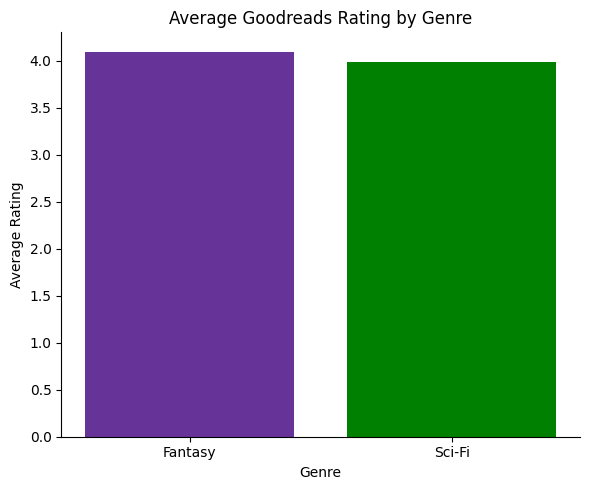

In [21]:
#bar chart showing fantasy gets more high ratings
avg_ratings = books_df.groupby("genre")["avg_rate"].mean()

plt.figure(figsize=(6,5))

plt.bar(
    avg_ratings.index,
    avg_ratings.values,
    color=["rebeccapurple", "green"]
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title("Average Goodreads Rating by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.show()

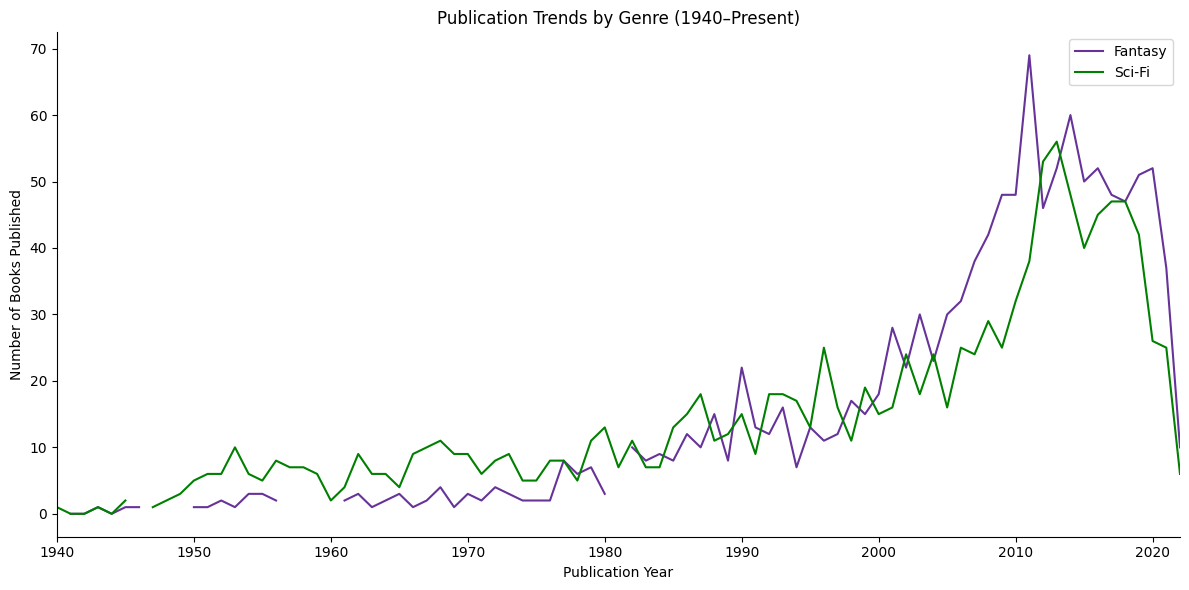

In [22]:
#line plot showing the most prevalent genere per year. it shows in the early years Sci-Fi was on top and later years would show Fantasy dominating
books_df["pub_year"] = pd.to_numeric(
    books_df["pub_year"],
    errors="coerce"
)

filtered_books = books_df[
    books_df["pub_year"] >= 1940
]

yearly_counts = filtered_books.groupby(
    ["pub_year", "genre"]
).size().unstack()

# Fill missing years
all_years = range(
    1940,
    int(yearly_counts.index.max()) + 1
)

yearly_counts = yearly_counts.reindex(
    all_years,
    fill_value=0
)

plt.figure(figsize=(12,6))

# Fantasy = purple
plt.plot(
    yearly_counts.index,
    yearly_counts["Fantasy"],
    color="rebeccapurple",
    label="Fantasy"
)

# Sci-Fi = green
plt.plot(
    yearly_counts.index,
    yearly_counts["Sci-Fi"],
    color="green",
    label="Sci-Fi"
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title("Publication Trends by Genre (1940–Present)")
plt.xlabel("Publication Year")
plt.ylabel("Number of Books Published")

plt.xlim(1940, yearly_counts.index.max())

plt.legend()

plt.tight_layout()
plt.show()

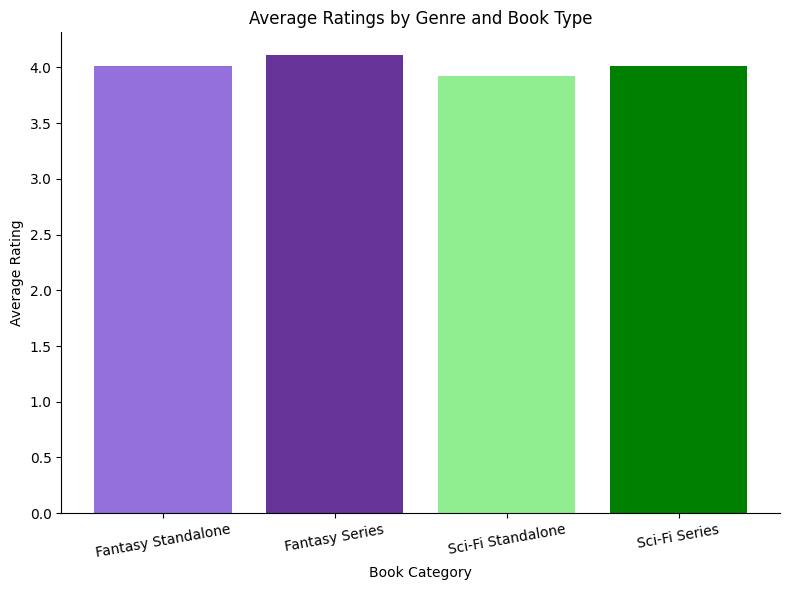

In [23]:
# Create grouped averages by genre and series status showing that series tend to get higher ratings
series_ratings = books_df.groupby(
    ["genre", "is_series"]
)["avg_rate"].mean()

# Create labels and values
labels = [
    "Fantasy Standalone",
    "Fantasy Series",
    "Sci-Fi Standalone",
    "Sci-Fi Series"
]

values = [
    series_ratings["Fantasy"]["Standalone"],
    series_ratings["Fantasy"]["Series"],
    series_ratings["Sci-Fi"]["Standalone"],
    series_ratings["Sci-Fi"]["Series"]
]

# Set colors
colors = [
    "mediumpurple",
    "rebeccapurple",
    "lightgreen",
    "green"
]

plt.figure(figsize=(8,6))

plt.bar(
    labels,
    values,
    color=colors
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title("Average Ratings by Genre and Book Type")
plt.xlabel("Book Category")
plt.ylabel("Average Rating")

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

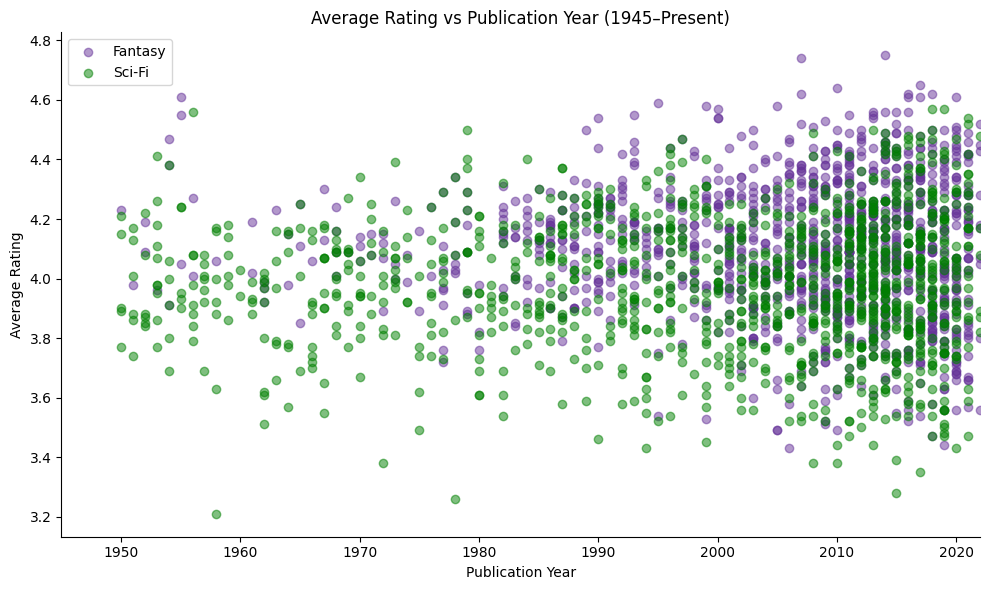

In [24]:
#scatter plot showing publishing year vs genere showing fantast consistantly on top with more scifi titles early on and more fantasy books appearing in the later years
# Filter books published from 1950 onward
filtered_books = books_df[books_df["pub_year"] >= 1950]

# Separate genres
fantasy_books = filtered_books[
    filtered_books["genre"] == "Fantasy"
]

scifi_books = filtered_books[
    filtered_books["genre"] == "Sci-Fi"
]

plt.figure(figsize=(10,6))

# Fantasy = purple
plt.scatter(
    fantasy_books["pub_year"],
    fantasy_books["avg_rate"],
    alpha=0.5,
    color="rebeccapurple",
    label="Fantasy"
)

# Sci-Fi =  green
plt.scatter(
    scifi_books["pub_year"],
    scifi_books["avg_rate"],
    alpha=0.5,
    color="green",
    label="Sci-Fi"
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title("Average Rating vs Publication Year (1945–Present)")
plt.xlabel("Publication Year")
plt.ylabel("Average Rating")

plt.xlim(1945, filtered_books["pub_year"].max())

plt.legend()

plt.tight_layout()
plt.show()